# **Caso 3**

In [31]:
import numpy as np
import matplotlib.pyplot as plt

### Simular una VA discreta

In [32]:

def simular_discreta():
  u = np.random.random(1)[0]
  if u < 0.2:
    return 1
  elif u < 0.6:
    return 2
  else:
    return 3

a = simular_discreta()
print(a)

3


### CDF de X

In [33]:
def F_inv(p, parameter):
  # Inversa de la CDF que vamos a usar
  return -np.log(1-p)/parameter

### Simulación de una VA con distribución exponencial de parámetro 1/10

In [34]:
u = np.random.random(1)[0] # Valor aleatorio entre 0 y 1 (recordar que u es un "sampleo" de la VA U ~ Uniforme(0,1))
print('     u =',u)

F_X_u = F_inv(u, 1/10) # CDF de X evaluada en el valor u
print('F_X(u) =',F_X_u)

     u = 0.8489916130448953
F_X(u) = 18.904199009606167


### Histograma de varias generaciones de una VA con distribución Exp(1/10)

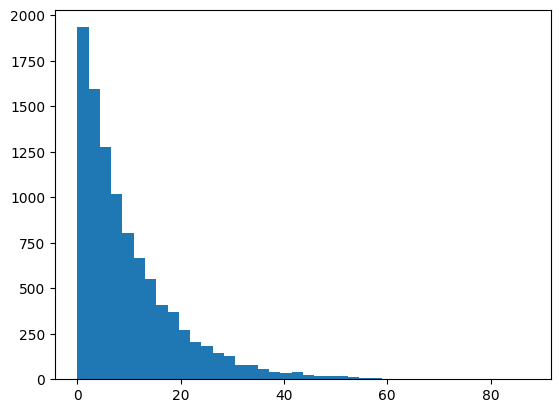

In [35]:
lamb = 1/10
y = [F_inv(np.random.random(1)[0], lamb) for i in range(10000)]
plt.hist(y, bins = 40)
plt.show()
    

### Histograma + PDF

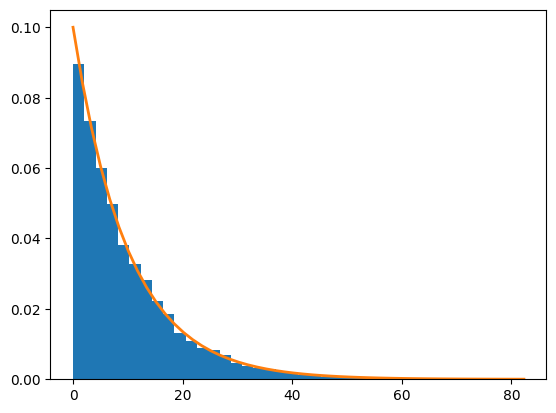

In [36]:
y = [F_inv(np.random.random(1)[0], lamb) for i in range(10000)]
myHist = plt.hist(y, bins = 40, density=True) # histograma que muestra ahora la frecuencia relativa
x = np.linspace(0,np.max(y))
h = plt.plot(x, lamb*np.exp(-lamb*x), lw=2)
plt.show()

### Alice vs. Bob

Alice gana en una fraccion 0.5406 de las simulaciones


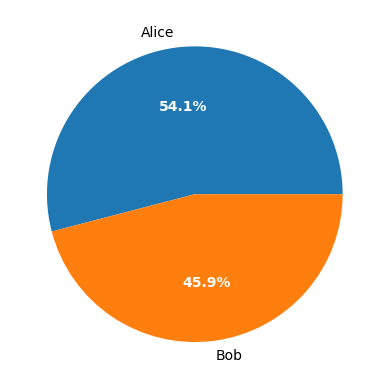

In [37]:
def Partida(p_0, p_1):
  # Simula una partida. Retorna 1 si gana el primero, retorna 0 si gana el segundo.
  perf_0 = F_inv(np.random.rand(), p_0)
  perf_1 = F_inv(np.random.rand(), p_1)  
  if perf_0>perf_1:
    return 0
  else:
    return 1

N = 10000    #Numero de simulaciones

param_A = 1/7
param_B = 1/6

win_A = 0   # Cuenta cuantas veces gana Alice

for i in range(N):
  win_A += 1-Partida(param_A, param_B)

# Graficar resultado
_,_,sliceText = plt.pie([win_A, N-win_A], labels=["Alice", "Bob"], autopct='%1.1f%%')
plt.setp(sliceText, color='white', fontweight='bold')
print("Alice gana en una fraccion "+ str(win_A/N)+" de las simulaciones")

### Torneo

Alice gana en una fraccion 0.2933 de las simulaciones


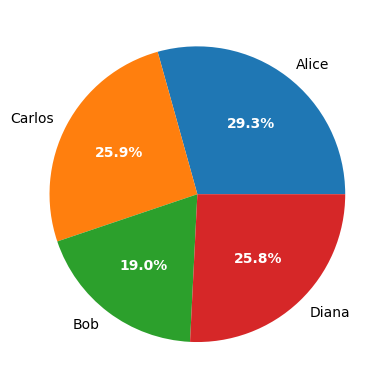

In [ ]:
def Torneo(p_0, p_1, p_2, p_3):
  # Simula un torneo. Primero juega p_0 vs p_1 y p_2 vs p_3. Luego una final entre los ganadores.
  # Entrega el indice del ganador (0, 1, 2 o 3).
  P=[p_0,p_1,p_2,p_3]
  # 0 vs 1
  winner_semi_1 = Partida(p_0, p_1) # da 0 si gana p_0, da 1 si gana p_1
  # 2 vs 3
  winner_semi_2 = 2+Partida(p_2, p_3) # da 2 si gana p_2, da 3 si gana p_3
  # Final
  if Partida(P[winner_semi_1], P[winner_semi_2]) == 1:
    return winner_semi_1
  else:
    return winner_semi_2

# Parametro de cada participante
Parametros = {"Alice":1/7, "Bob":1/6, "Carlos":1/5, "Diana":1/10}

N=10000
Frecuencias = [0,0,0,0] # gana Alice, Carlos, Bob, Diana

# Semi_1: Alice vs Bob
# Semi_2: Carlos vs Diana
for i in range(N):
  Frecuencias[Torneo(Parametros["Alice"], Parametros["Bob"], Parametros["Carlos"], Parametros["Diana"])] += 1

# Graficar resultados
_,_,sliceText = plt.pie(Frecuencias, labels = ["Alice","Carlos","Bob","Diana"], autopct='%1.1f%%')
plt.setp(sliceText, color='white', fontweight='bold')
print("Alice gana en una fraccion "+ str(Frecuencias[0]/N) +" de las simulaciones")

### El mejor match para Alice

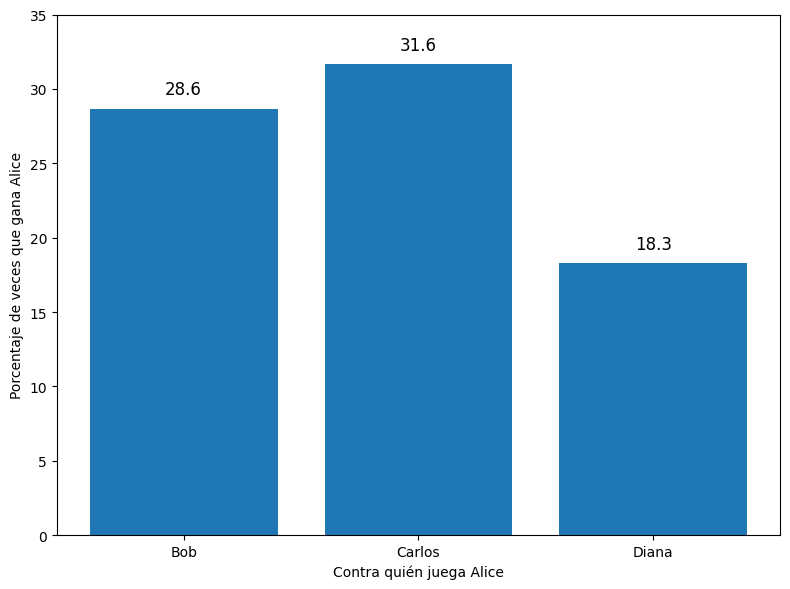

In [18]:
N = 10000    # Numero de simulaciones


# Simulacion del torneo cuando parte con Bob
Frecuencias_vs_Bob = [0,0,0,0]
for i in range(N):
  Frecuencias_vs_Bob[Torneo(Parametros["Alice"], Parametros["Bob"], Parametros["Carlos"], Parametros["Diana"])] += 1

# Simulacion del torneo cuando parte con Carlos
Frecuencias_vs_Carlos = [0,0,0,0]
for i in range(N):
  Frecuencias_vs_Carlos[Torneo(Parametros["Alice"], Parametros["Carlos"], Parametros["Bob"], Parametros["Diana"])] += 1

# Simulacion del torneo cuando parte con Diana
Frecuencias_vs_Diana = [0,0,0,0]
for i in range(N):
  Frecuencias_vs_Diana[Torneo(Parametros["Alice"], Parametros["Diana"], Parametros["Carlos"], Parametros["Bob"])] += 1


# Graficar resultados
y = [Frecuencias_vs_Bob[0]*100/N, Frecuencias_vs_Carlos[0]*100/N, Frecuencias_vs_Diana[0]*100/N]
plt.figure(figsize=(8, 6))  

plt.bar(["Bob", "Carlos", "Diana"], y)
plt.ylim(0, 35) 
plt.ylabel("Porcentaje de veces que gana Alice")
plt.xlabel("Contra quién juega Alice")


for i in range(len(y)):
    plt.text(i, y[i] + 1, np.round(y[i], 1), ha='center', fontsize=12)

plt.tight_layout()
plt.show()
